# Create Renewable Energy Zones mask

In [1]:
import xarray as xr
import geopandas
import regionmask

In [2]:
# def create_mask(gpd_df, template_ds, boundary=None, lon_name='lon', lat_name='lat'):
#     """
#     Create mask from shapefiles and a template xarray dataArray or dataset.
#     """
#     mask = regionmask.mask_3D_geopandas(
#         gpd_df,
#         template_ds[lon_name],
#         template_ds[lat_name]
#     )
    
#     if lon_name != 'lon':
#         mask = mask.rename({lon_name: 'lon'})
#     if lat_name != 'lat':
#         mask = mask.rename({lat_name: 'lat'})
        
#     if isinstance(boundary, list):
#         mask = mask.sel(
#             lon=slice(boundary[0], boundary[1]),
#             lat=slice(boundary[2], boundary[3])
#         )
        
#     return mask

In [3]:
# ALready computed shapefile from other project
rez_gpd = geopandas.read_file(
    "/g/data/w42/dr6273/work/projects/Aus_energy/data/resource_coded_Indicative_REZ_boundaries_2024_GIS_data.shp"
)

In [4]:
rez_gpd.head()

,Name,Type,code_2023,code_SC205,longitude,latitude,geometry
0,Q1 Far North QLD,REZ,1,1,145.123721,-16.187650,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -..."
1,Q2 North Qld Clean Energy Hub,REZ,3,3,144.062266,-19.110858,"POLYGON Z ((143.72015 -16.97938 0, 143.87955 -..."
2,Q3 Northern Qld,REZ,2,2,146.333143,-19.197589,"POLYGON Z ((146.27782 -18.7192 0, 146.28263 -1..."
3,Q4 Isaac,REZ,3,3,148.339869,-21.393793,"POLYGON Z ((147.64366 -19.94015 0, 147.68341 -..."
4,Q5 Barcaldine,REZ,2,3,145.595326,-22.855731,"POLYGON Z ((145.82086 -23.84279 0, 145.7004 -2..."


In [5]:
barra_instance = xr.open_dataset(
    "/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/fx/orog/latest/orog_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1.nc"
)

In [6]:
barra_instance.dims

FrozenMappingWarningOnValuesAccess({'lat': 646, 'lon': 1082})

In [7]:
rez_mask = fn.create_mask(
    rez_gpd,
    barra_instance,
    [110, 155, -45, -10]
)

In [8]:
rez_codes = rez_gpd["Name"]
rez_codes = [i.split(" ")[0] for i in rez_codes]

In [9]:
rez_mask = rez_mask.assign_coords({
    "region": rez_codes
})

In [10]:
rez_mask = rez_mask.drop("crs")

/jobfs/153563043.gadi-pbs/ipykernel_3148903/1218372899.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  rez_mask = rez_mask.drop("crs")


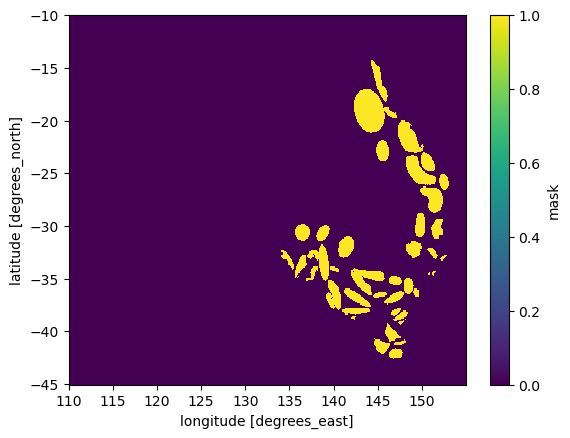

In [11]:
rez_mask.sum("region").plot()

In [13]:
rez_mask_ds = rez_mask.to_dataset(name='REZ')
rez_mask_ds.to_netcdf('/g/data/w42/dr6273/work/projects/Aus_energy/data/rez_2024_mask_BARRA-R2_grid.nc')